In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')

from funcs import *
from processing_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_130126/20cm/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm')

%load_ext autoreload
%autoreload 2

# Scaling waves

## Method for scaling

Take one original wave at depth $H_1$, with wave steepness $k_1*a_1$ and relative depth $k_1*H_1$. We want to scale this wave by keeping these two constant.
So for a new wave with depth $H_2$, we should have:

$k_1*a_1 = k_2*a_2$ and $k_1*H_1 = k_2*H_2$.

So,
$$k_2 = \frac{k_1 H_1}{H_2}$$
$$a_2 = \frac{k_1 a_1}{k_2} = \frac{a_1 H_2}{H_1}$$

And thus for the dispersion relation,
$$\omega_1^2 = gk_1 tanh(k_1 H_1)$$
$$\omega_2^2 = gk_2 tanh(k_2 H_2)$$

but with $k_1*H_1 = k_2*H_2$ we have that $tanh(k_1 H_1) = tanh(k_2 H_2)$.

So,
$$\omega_2^2 = g k_2 \frac{\omega_1^2}{g k_1} = \frac{k_2}{k_1}\omega_1^2$$
$$\omega_2 = \omega_1 \sqrt{\frac{k_2}{k_1}} = \omega_1 \sqrt{\frac{H_1}{H_2}}$$

### Reminder of wave properties
* The wavelength is $\lambda = \frac{2 \pi}{k}$
* Wave period is $T = \frac{2 \pi}{\omega} = \frac{1}{f}$
* Frequency is $f = \frac{1}{T}$
* Angular frequency $\omega = 2\pi f$
* Phase speed, $c = \frac{\omega}{k} = f \lambda$

### Writing the scaled wave properties to txt file

In [2]:
frequencies = ['f11', 'f12', 'f13', 'f14', 'f15']
freqs = [1.1, 1.2, 1.3, 1.4, 1.5]
amplitudes = ['a01', 'a02', 'a03']
H_1 = 0.20 # in meters
H_2 = 0.30 # in meters

output_file = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/scale_20_to_30_1_new.txt'

""" for f, fr in zip(frequencies, freqs):
    for a in amplitudes:
        print(f'{f}_{a}')
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_1 = data_lines[19].split()[1]
            k_1 = data_lines[5].split()[1]
            lambda_1 = data_lines[4].split()[1]
            w_1 = 2*np.pi*fr
            
            with open(output_file, 'a') as file:
                file.write(f'Scaling from 20cm to 30cm - {f}_{a}\n')
                file.write('\n')
                file.write('Wave parameters at 20cm:\n')
                file.write(f'Frequency (Hz): {fr}\n')
                file.write(f'Angular frequency (rad/s): {w_1}\n')
                file.write(f'Amplitude at P0 (m): {a_1}\n')
                file.write(f'Wave number (1/m): {k_1}\n')
                file.write(f'Wavelength (m): {lambda_1}\n')
                file.write(f'ak value at 20cm: {float(a_1) * float(k_1)}\n')
                file.write(f'kH value at 20cm: {float(k_1) * H_1}\n\n')

                file.write('Scaled wave parameters at 30cm:\n')
                w_2 = w_1 * np.sqrt(H_1 / H_2)
                f_2 = w_2 / (2 * np.pi)
                a_2 = float(a_1)* H_2 / H_1
                k_2 = float(k_1) * H_1 / H_2
                lambda_2 = 2 * np.pi / k_2

                file.write(f'Frequency (Hz): {f_2}\n')
                file.write(f'Angular frequency (rad/s): {w_2}\n')
                file.write(f'Amplitude at P0 (m): {a_2}\n')
                file.write(f'Wave number (1/m): {k_2}\n')
                file.write(f'Wavelength (m): {lambda_2}\n')
                file.write(f'ak value at 30cm: {float(a_2) * float(k_2)}\n')
                file.write(f'kH value at 30cm: {float(k_2) * H_2}\n')

                file.write('--------------------------------\n\n') """

" for f, fr in zip(frequencies, freqs):\n    for a in amplitudes:\n        print(f'{f}_{a}')\n        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:\n            data = file.read()\n            data_lines = data.splitlines()\n\n            a_1 = data_lines[19].split()[1]\n            k_1 = data_lines[5].split()[1]\n            lambda_1 = data_lines[4].split()[1]\n            w_1 = 2*np.pi*fr\n            \n            with open(output_file, 'a') as file:\n                file.write(f'Scaling from 20cm to 30cm - {f}_{a}\n')\n                file.write('\n')\n                file.write('Wave parameters at 20cm:\n')\n                file.write(f'Frequency (Hz): {fr}\n')\n                file.write(f'Angular frequency (rad/s): {w_1}\n')\n                file.write(f'Amplitude at P0 (m): {a_1}\n')\n                file.write(f'Wave number (1/m): {k_1}\n')\n                file.write(f'Wavelength (m): 

In [ ]:
frequencies = ['f16', 'f17', 'f18']
freqs = [1.6, 1.7, 1.8]
amplitudes = ['a01', 'a02', 'a025', 'a03']

H_1 = 0.20 # in meters
H_2 = 0.30 # in meters

output_file = '/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/scale_20_to_30_2.txt'

""" for f, fr in zip(frequencies, freqs):
    for a in amplitudes:
        print(f'{f}_{a}')
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_1 = data_lines[19].split()[1]
            k_1 = data_lines[5].split()[1]
            lambda_1 = data_lines[4].split()[1]
            w_1 = 2*np.pi*fr
            
            with open(output_file, 'a') as file:
                file.write(f'Scaling from 20cm to 30cm - {f}_{a}\n')
                file.write('\n')
                file.write('Wave parameters at 20cm:\n')
                file.write(f'Frequency (Hz): {fr}\n')
                file.write(f'Angular frequency (rad/s): {w_1}\n')
                file.write(f'Amplitude at P0 (m): {a_1}\n')
                file.write(f'Wave number (1/m): {k_1}\n')
                file.write(f'Wavelength (m): {lambda_1}\n')
                file.write(f'ak value at 20cm: {float(a_1) * float(k_1)}\n')
                file.write(f'kH value at 20cm: {float(k_1) * H_1}\n\n')

                file.write('Scaled wave parameters at 30cm:\n')
                w_2 = w_1 * np.sqrt(H_1 / H_2)
                f_2 = w_2 / (2 * np.pi)
                a_2 = float(a_1)* H_2 / H_1
                k_2 = float(k_1) * H_1 / H_2
                lambda_2 = 2 * np.pi / k_2

                file.write(f'Frequency (Hz): {f_2}\n')
                file.write(f'Angular frequency (rad/s): {w_2}\n')
                file.write(f'Amplitude at P0 (m): {a_2}\n')
                file.write(f'Wave number (1/m): {k_2}\n')
                file.write(f'Wavelength (m): {lambda_30}\n')
                file.write(f'ak value at 30cm: {float(a_2) * float(k_2)}\n')
                file.write(f'kH value at 30cm: {float(k_2) * H_2}\n')

                file.write('--------------------------------\n\n') """

## Converting real amplitude to wave maker setting - volt

In [3]:
# The measured real amplitudes at 20 cm water depth

frequencies = ['f11', 'f12', 'f13', 'f14', 'f15']
freqs = [1.1, 1.2, 1.3, 1.4, 1.5]
amplitudes = ['a01', 'a02', 'a03']
volts = [0.1, 0.2, 0.3]

real_amps = []
volt_amps = []

for f, fr in zip(frequencies, freqs):
    for a, v in zip(amplitudes, volts):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_20 = data_lines[19].split()[1]
            real_amps.append(a_20)
            volt_amps.append(v)

frequencies = ['f16', 'f17', 'f18']
freqs = [1.6, 1.7, 1.8]
amplitudes = ['a01', 'a02', 'a025', 'a03']
volts = [0.1, 0.2, 0.25, 0.3]   

for f, fr in zip(frequencies, freqs):
    for a, v in zip(amplitudes, volts):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/20cm/20cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_20 = data_lines[19].split()[1]
            real_amps.append(a_20)
            volt_amps.append(v)

real_amps_20 = np.asarray([float(i) for i in real_amps])
volt_amps_20 = np.asarray(volt_amps)

In [4]:
f11_volt_amps_20 = volt_amps_20[0:3]
f11_real_amps_20 = real_amps_20[0:3]

f12_volt_amps_20 = volt_amps_20[3:6]
f12_real_amps_20 = real_amps_20[3:6]

f13_volt_amps_20 = volt_amps_20[6:9]
f13_real_amps_20 = real_amps_20[6:9]

f14_volt_amps_20 = volt_amps_20[9:12]
f14_real_amps_20 = real_amps_20[9:12]

f15_volt_amps_20 = volt_amps_20[12:15]
f15_real_amps_20 = real_amps_20[12:15]

f16_volt_amps_20 = volt_amps_20[15:19]
f16_real_amps_20 = real_amps_20[15:19]

f17_volt_amps_20 = volt_amps_20[19:23]
f17_real_amps_20 = real_amps_20[19:23]

f18_volt_amps_20 = volt_amps_20[23:27]
f18_real_amps_20 = real_amps_20[23:27]

In [24]:
# The measured real amplitudes at 30 cm water depth

frequencies_1 = ['f0898']  # ran with amps = 0.15, 0.3, 0.45
freqs_1 = [0.898]
amplitudes_1 = ['a015', 'a03', 'a045']
volts_1 = [0.15, 0.3, 0.45]

frequencies_2 = ['f0980'] # ran with amps = 0.1, 0.15, 0.2, 0.3
freqs_2 = [0.980]
amplitudes_2 = ['a01','a015', 'a02', 'a03']
volts_2 = [0.1, 0.15, 0.2, 0.3]

frequencies_3 = ['f1061']  # ran with amps = 0.1, 0.2, 0.3
freqs_3 = [1.061]
amplitudes_3 = ['a01', 'a02', 'a03']
volts_3 = [0.1, 0.2, 0.3]

frequencies_4 = ['f1143']  # ran with amps = 0.15, 0.3, 0.45
freqs_4 = [1.143]
amplitudes_4 = ['a015', 'a03', 'a045']
volts_4 = [0.15, 0.3, 0.45]

frequencies_5 = ['f1225']  # ran with amps = 0.1, 0.2, 0.3
freqs_5 = [1.225]
amplitudes_5 = ['a01', 'a02', 'a03']
volts_5 = [0.1, 0.2, 0.3]

frequencies_6 = ['f1306', 'f1388', 'f1470']  # ran with amps = 0.1, 0.2, 0.25, 0.3
freqs_6 = [1.306, 1.388, 1.470]
amplitudes_6 = ['a01', 'a02', 'a025', 'a03']
volts_6 = [0.1, 0.2, 0.25, 0.3]

real_amps = []
volt_amps = []

for f, fr in zip(frequencies_1, freqs_1):
    for a, v in zip(amplitudes_1, volts_1):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/30cm/volt_to_meter_runs/30cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_30 = data_lines[19].split()[1]
            real_amps.append(a_30)
            volt_amps.append(v)  

for f, fr in zip(frequencies_2, freqs_2):
    for a, v in zip(amplitudes_2, volts_2):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/30cm/volt_to_meter_runs/30cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_30 = data_lines[19].split()[1]
            real_amps.append(a_30)
            volt_amps.append(v)

for f, fr in zip(frequencies_3, freqs_3):
    for a, v in zip(amplitudes_3, volts_3):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/30cm/volt_to_meter_runs/30cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_30 = data_lines[19].split()[1]
            real_amps.append(a_30)
            volt_amps.append(v)

for f, fr in zip(frequencies_4, freqs_4):
    for a, v in zip(amplitudes_4, volts_4):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/30cm/volt_to_meter_runs/30cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_30 = data_lines[19].split()[1]
            real_amps.append(a_30)
            volt_amps.append(v)

for f, fr in zip(frequencies_5, freqs_5):
    for a, v in zip(amplitudes_5, volts_5):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/30cm/volt_to_meter_runs/30cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_30 = data_lines[19].split()[1]
            real_amps.append(a_30)
            volt_amps.append(v)

for f, fr in zip(frequencies_6, freqs_6):
    for a, v in zip(amplitudes_6, volts_6):
        with open(f'/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Results/No plates/30cm/volt_to_meter_runs/30cm_{f}_{a}_wave_parameters.txt', 'r') as file:
            data = file.read()
            data_lines = data.splitlines()

            a_30 = data_lines[19].split()[1]
            real_amps.append(a_30)
            volt_amps.append(v)


real_amps = np.asarray([float(i) for i in real_amps])
volt_amps = np.asarray(volt_amps)

In [26]:
f11_volt_amps_30 = volt_amps[0:3]
f11_real_amps_30 = real_amps[0:3]

f12_volt_amps_30 = volt_amps[3:7]
f12_real_amps_30 = real_amps[3:7]

f13_volt_amps_30 = volt_amps[7:10]
f13_real_amps_30 = real_amps[7:10]

f14_volt_amps_30 = volt_amps[10:13]
f14_real_amps_30 = real_amps[10:13]

f15_volt_amps_30 = volt_amps[13:16]
f15_real_amps_30 = real_amps[13:16]

f16_volt_amps_30 = volt_amps[16:20]
f16_real_amps_30 = real_amps[16:20]

f17_volt_amps_30 = volt_amps[20:24]
f17_real_amps_30 = real_amps[20:24]

f18_volt_amps_30 = volt_amps[24:28]
f18_real_amps_30 = real_amps[24:28]

Text(0.5, 0.98, 'Measured wave amplitudes and voltage amplitude')

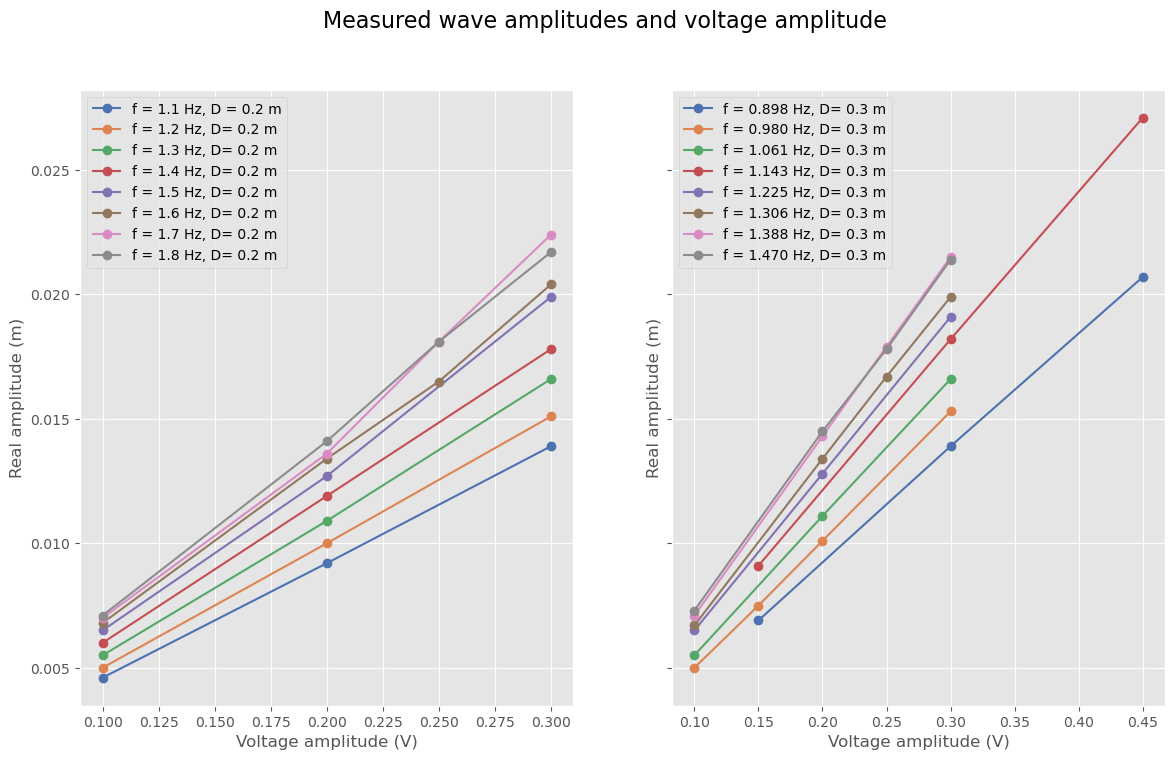

In [36]:
palette = sns.color_palette("deep", 8)

fig, ax = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

# 20 cm
ax[0].plot(f11_volt_amps_20, f11_real_amps_20, 'o-', color=palette[0], label='f = 1.1 Hz, D = 0.2 m')
ax[0].plot(f12_volt_amps_20, f12_real_amps_20, 'o-', color=palette[1], label='f = 1.2 Hz, D= 0.2 m')
ax[0].plot(f13_volt_amps_20, f13_real_amps_20, 'o-', color=palette[2], label='f = 1.3 Hz, D= 0.2 m')
ax[0].plot(f14_volt_amps_20, f14_real_amps_20, 'o-', color=palette[3], label='f = 1.4 Hz, D= 0.2 m')
ax[0].plot(f15_volt_amps_20, f15_real_amps_20, 'o-', color=palette[4], label='f = 1.5 Hz, D= 0.2 m')
ax[0].plot(f16_volt_amps_20, f16_real_amps_20, 'o-', color=palette[5], label='f = 1.6 Hz, D= 0.2 m')
ax[0].plot(f17_volt_amps_20, f17_real_amps_20, 'o-', color=palette[6], label='f = 1.7 Hz, D= 0.2 m')
ax[0].plot(f18_volt_amps_20, f18_real_amps_20, 'o-', color=palette[7], label='f = 1.8 Hz, D= 0.2 m')

# 30 cm
ax[1].plot(f11_volt_amps_30, f11_real_amps_30, 'o-', color=palette[0], label='f = 0.898 Hz, D= 0.3 m')
ax[1].plot(f12_volt_amps_30, f12_real_amps_30, 'o-', color=palette[1], label='f = 0.980 Hz, D= 0.3 m')
ax[1].plot(f13_volt_amps_30, f13_real_amps_30, 'o-', color=palette[2], label='f = 1.061 Hz, D= 0.3 m')
ax[1].plot(f14_volt_amps_30, f14_real_amps_30, 'o-', color=palette[3], label='f = 1.143 Hz, D= 0.3 m')
ax[1].plot(f15_volt_amps_30, f15_real_amps_30, 'o-', color=palette[4], label='f = 1.225 Hz, D= 0.3 m')
ax[1].plot(f16_volt_amps_30, f16_real_amps_30, 'o-', color=palette[5], label='f = 1.306 Hz, D= 0.3 m')
ax[1].plot(f17_volt_amps_30, f17_real_amps_30, 'o-', color=palette[6], label='f = 1.388 Hz, D= 0.3 m')
ax[1].plot(f18_volt_amps_30, f18_real_amps_30, 'o-', color=palette[7], label='f = 1.470 Hz, D= 0.3 m')

ax[0].legend(loc = 'upper left')
ax[0].set_xlabel('Voltage amplitude (V)')
ax[0].set_ylabel('Real amplitude (m)')

ax[1].legend(loc = 'upper left')
ax[1].set_xlabel('Voltage amplitude (V)')
ax[1].set_ylabel('Real amplitude (m)')

fig.suptitle('Measured wave amplitudes and voltage amplitude', fontsize=16)

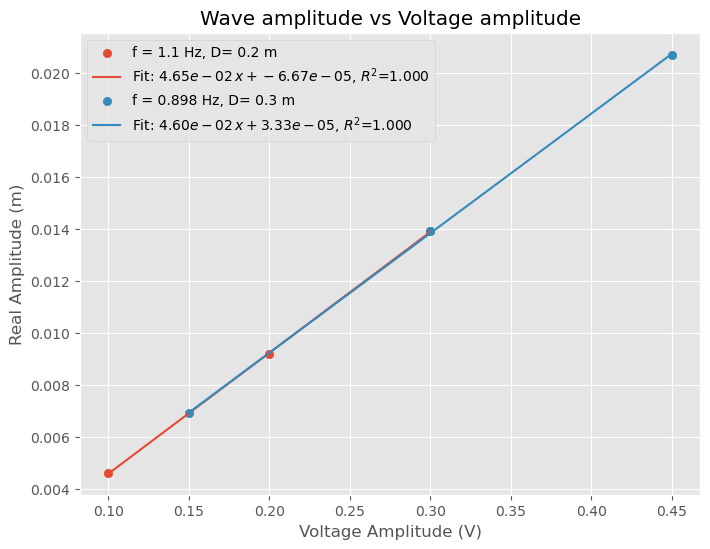

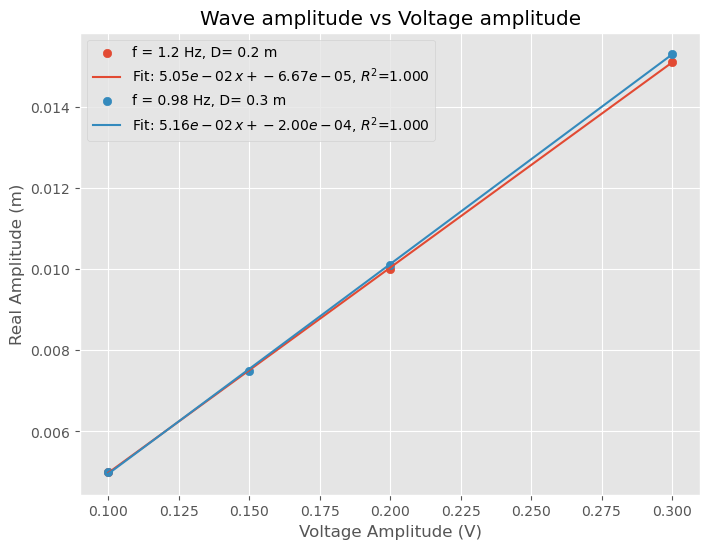

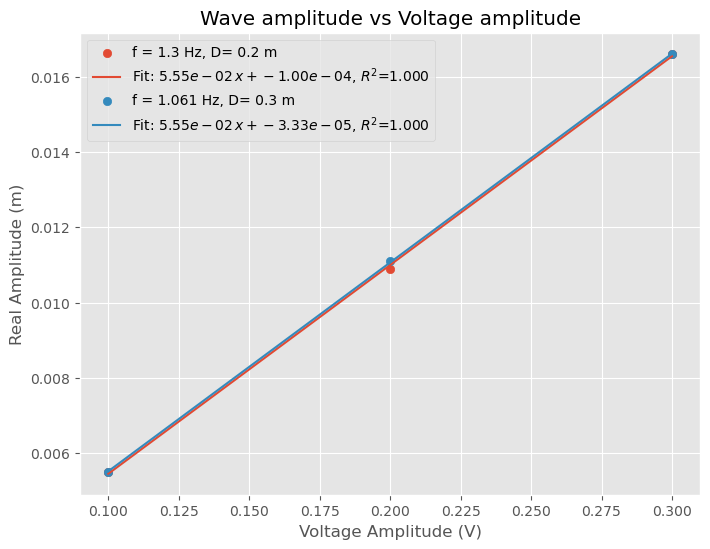

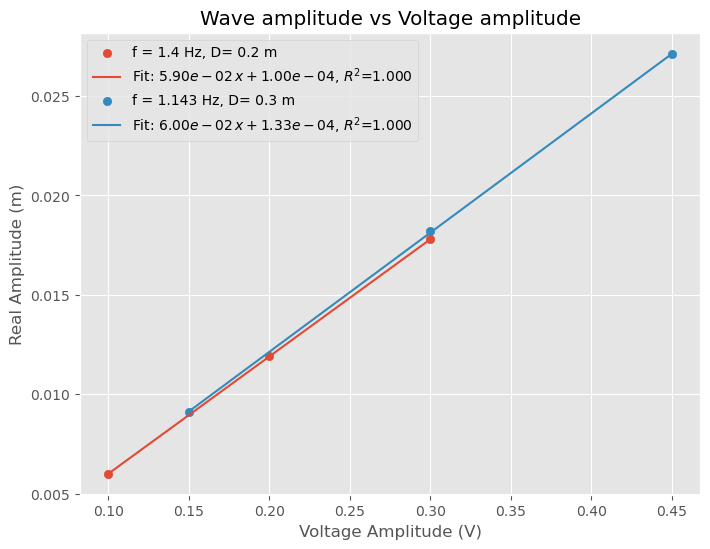

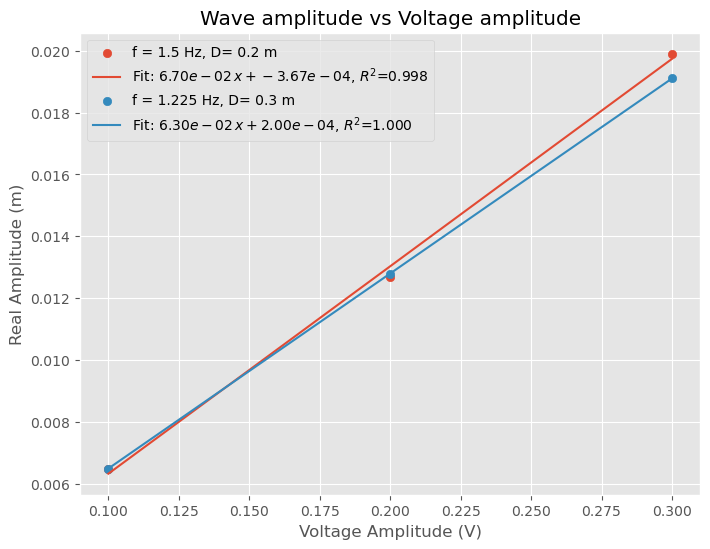

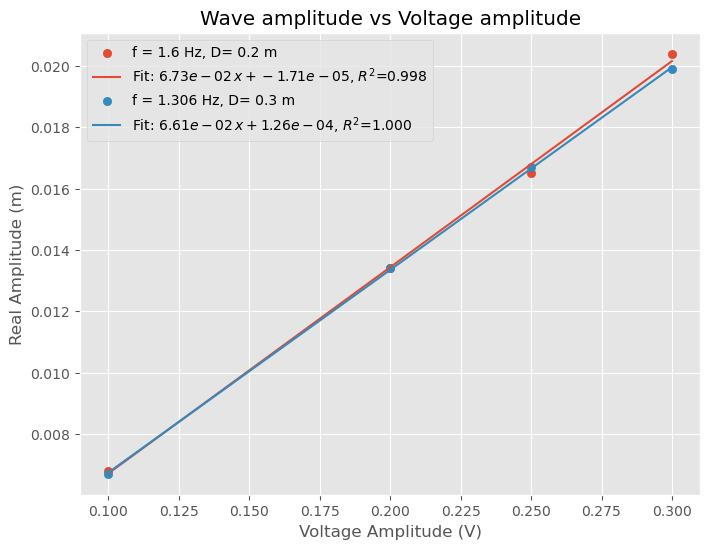

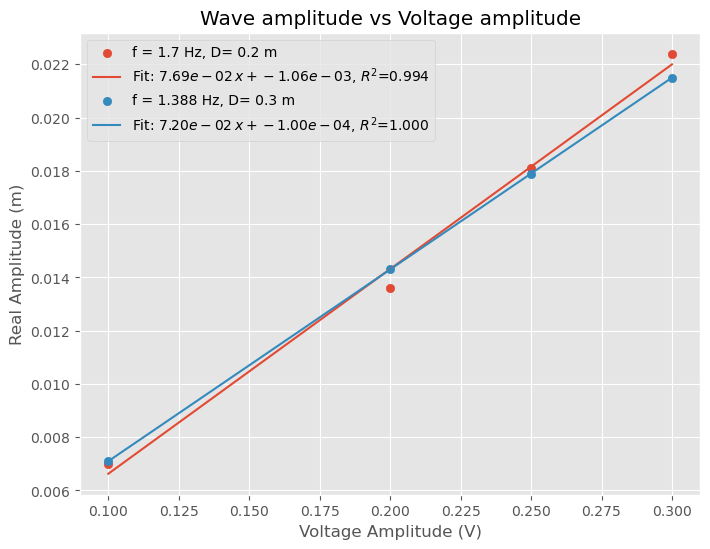

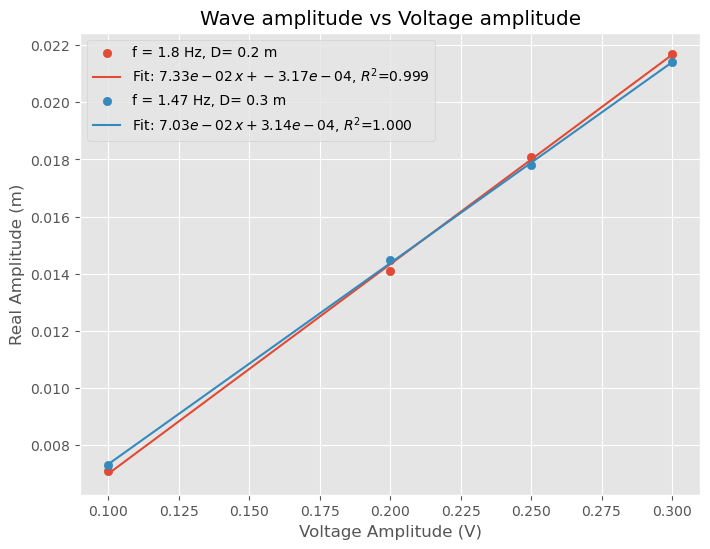

In [29]:
# Linear regression of real amplitude vs volt amplitude

# 20 cm
volt_list_20 = [f11_volt_amps_20, f12_volt_amps_20, f13_volt_amps_20,
             f14_volt_amps_20, f15_volt_amps_20, f16_volt_amps_20,
             f17_volt_amps_20, f18_volt_amps_20]

real_list_20 = [f11_real_amps_20, f12_real_amps_20, f13_real_amps_20,
             f14_real_amps_20, f15_real_amps_20, f16_real_amps_20,
             f17_real_amps_20, f18_real_amps_20]

freqs_20 = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8]

# 30 cm
volt_list_30 = [f11_volt_amps_30, f12_volt_amps_30, f13_volt_amps_30,
             f14_volt_amps_30, f15_volt_amps_30, f16_volt_amps_30, 
             f17_volt_amps_30, f18_volt_amps_30]

real_list_30 = [f11_real_amps_30, f12_real_amps_30, f13_real_amps_30,
             f14_real_amps_30, f15_real_amps_30, f16_real_amps_30,
             f17_real_amps_30, f18_real_amps_30]

freqs_30 = [0.898, 0.980, 1.061, 1.143, 1.225, 1.306, 1.388, 1.470]

results_20 = []
results_30 = []

for volt_20, real_20, freq_20, volt_30, real_30, freq_30 in zip(volt_list_20, real_list_20, freqs_20, volt_list_30, real_list_30, freqs_30):
    volt_20 = np.asarray(volt_20, dtype=float)
    real_20 = np.asarray(real_20, dtype=float)
    volt_30 = np.asarray(volt_30, dtype=float)
    real_30 = np.asarray(real_30, dtype=float)

    # Fit linear model real = slope * volt + intercept
    coeff_20 = np.polyfit(volt_20, real_20, 1)
    slope_20, intercept_20 = float(coeff_20[0]), float(coeff_20[1])

    coeff_30 = np.polyfit(volt_30, real_30, 1)
    slope_30, intercept_30 = float(coeff_30[0]), float(coeff_30[1])

    line_20 = np.poly1d(coeff_20)
    r2_20 = r2_score(real_20, line_20(volt_20)) 

    line_30 = np.poly1d(coeff_30)
    r2_30 = r2_score(real_30, line_30(volt_30))

    results_20.append({
        "frequency": float(freq_20),
        "a_20": real_20,
        "V_20": volt_20,
        "slope": slope_20,
        "intercept": intercept_20,
        "r2": float(r2_20)
    })

    results_30.append({
        "frequency": float(freq_30),
        "a_30": real_30,
        "V_30": volt_30,
        "slope": slope_30,
        "intercept": intercept_30,
        "r2": float(r2_30)
    })

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(volt_20, real_20, label=f'f = {freq_20} Hz, D= 0.2 m')
    xx = np.linspace(volt_20.min(), volt_20.max(), 300)
    ax.plot(xx, line_20(xx),
            label=rf'Fit: ${slope_20:.2e}\,x + {intercept_20:.2e}$, $R^2$={r2_20:.3f}')
    
    ax.scatter(volt_30, real_30, label=f'f = {freq_30} Hz, D= 0.3 m')
    xx = np.linspace(volt_30.min(), volt_30.max(), 300)
    ax.plot(xx, line_30(xx),
            label=rf'Fit: ${slope_30:.2e}\,x + {intercept_30:.2e}$, $R^2$={r2_30:.3f}')
    
    ax.set_xlabel('Voltage Amplitude (V)')
    ax.set_ylabel('Real Amplitude (m)')
    ax.set_title('Wave amplitude vs Voltage amplitude')
    ax.legend()
    plt.show()

# Create DataFrame
df_20 = pd.DataFrame(results_20, columns=["frequency", "a_20", "V_20", "slope", "intercept", "r2"])
df_30 = pd.DataFrame(results_30, columns=["frequency", "a_30", "V_30", "slope", "intercept", "r2"])

In [30]:
df_20

,frequency,a_20,V_20,slope,intercept,r2
0,1.1,"[0.0046, 0.0092, 0.0139]","[0.1, 0.2, 0.3]",0.046500,-0.000067,0.999961
1,1.2,"[0.005, 0.01, 0.0151]","[0.1, 0.2, 0.3]",0.050500,-0.000067,0.999967
2,1.3,"[0.0055, 0.0109, 0.0166]","[0.1, 0.2, 0.3]",0.055500,-0.000100,0.999757
3,1.4,"[0.006, 0.0119, 0.0178]","[0.1, 0.2, 0.3]",0.059000,0.000100,1.000000
4,1.5,"[0.0065, 0.0127, 0.0199]","[0.1, 0.2, 0.3]",0.067000,-0.000367,0.998147
5,1.6,"[0.0068, 0.0134, 0.0165, 0.0204]","[0.1, 0.2, 0.25, 0.3]",0.067257,-0.000017,0.998432
6,1.7,"[0.007, 0.0136, 0.0181, 0.0224]","[0.1, 0.2, 0.25, 0.3]",0.076857,-0.001057,0.993760
7,1.8,"[0.0071, 0.0141, 0.0181, 0.0217]","[0.1, 0.2, 0.25, 0.3]",0.073257,-0.000317,0.999358


In [31]:
df_30

,frequency,a_30,V_30,slope,intercept,r2
0,0.898,"[0.0069, 0.0139, 0.0207]","[0.15, 0.3, 0.45]",0.046000,0.000033,0.999930
1,0.980,"[0.005, 0.0075, 0.0101, 0.0153]","[0.1, 0.15, 0.2, 0.3]",0.051600,-0.000200,0.999931
2,1.061,"[0.0055, 0.0111, 0.0166]","[0.1, 0.2, 0.3]",0.055500,-0.000033,0.999973
3,1.143,"[0.0091, 0.0182, 0.0271]","[0.15, 0.3, 0.45]",0.060000,0.000133,0.999959
4,1.225,"[0.0065, 0.0128, 0.0191]","[0.1, 0.2, 0.3]",0.063000,0.000200,1.000000
5,1.306,"[0.0067, 0.0134, 0.0167, 0.0199]","[0.1, 0.2, 0.25, 0.3]",0.066114,0.000126,0.999898
6,1.388,"[0.0071, 0.0143, 0.0179, 0.0215]","[0.1, 0.2, 0.25, 0.3]",0.072000,-0.000100,1.000000
7,1.470,"[0.0073, 0.0145, 0.0178, 0.0214]","[0.1, 0.2, 0.25, 0.3]",0.070286,0.000314,0.999762


The real amplitude to volt amplitude scale nearly linearily, such that we have a relation of voltage and meter on the form:

$$m = a*V + b$$
$$V = \frac{m - b}{a}$$

Knowing the target amplitude in meters, we can therefore find the needed amplitude in voltage from these curves.

In [ ]:
# Scaled frequencies from 20 cm to 30 cm water depth
scaled_freqs = []
freqs_20 = [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8]

for f in freqs_20:
    w_20 = 2 * np.pi * f
    w_30 = w_20 * np.sqrt(0.2 / 0.3)
    f_30 = w_30 / (2 * np.pi)
    scaled_freqs.append(f_30)

# Target real amplitudes (scaled from 20 cm) at 30 cm water depth
# Indicing frequencies
f0_real_amps_30 = f11_real_amps_20 * (0.3 / 0.2)
f1_real_amps_30 = f12_real_amps_20 * (0.3 / 0.2)
f2_real_amps_30 = f13_real_amps_20 * (0.3 / 0.2)
f3_real_amps_30 = f14_real_amps_20 * (0.3 / 0.2)
f4_real_amps_30 = f15_real_amps_20 * (0.3 / 0.2)
f5_real_amps_30 = f16_real_amps_20 * (0.3 / 0.2)
f6_real_amps_30 = f17_real_amps_20 * (0.3 / 0.2)
f7_real_amps_30 = f18_real_amps_20 * (0.3 / 0.2)

# Finding the corresponding volt amplitudes at 30 cm depth using the linear fits
f0_volt_amps_30 = (f0_real_amps_30 - df_30["intercept"].iloc[0]) / df_30["slope"].iloc[0]
f1_volt_amps_30 = (f1_real_amps_30 - df_30["intercept"].iloc[1]) / df_30["slope"].iloc[1]
f2_volt_amps_30 = (f2_real_amps_30 - df_30["intercept"].iloc[2]) / df_30["slope"].iloc[2]
f3_volt_amps_30 = (f3_real_amps_30 - df_30["intercept"].iloc[3]) / df_30["slope"].iloc[3]
f4_volt_amps_30 = (f4_real_amps_30 - df_30["intercept"].iloc[4]) / df_30["slope"].iloc[4]
f5_volt_amps_30 = (f5_real_amps_30 - df_30["intercept"].iloc[5]) / df_30["slope"].iloc[5]
f6_volt_amps_30 = (f6_real_amps_30 - df_30["intercept"].iloc[6]) / df_30["slope"].iloc[6]
f7_volt_amps_30 = (f7_real_amps_30 - df_30["intercept"].iloc[7]) / df_30["slope"].iloc[7]

scaled_volt_list = [f0_volt_amps_30, f1_volt_amps_30, f2_volt_amps_30,
             f3_volt_amps_30, f4_volt_amps_30, f5_volt_amps_30, f6_volt_amps_30, f7_volt_amps_30]

scaled_real_list = [f0_real_amps_30, f1_real_amps_30, f2_real_amps_30,
             f3_real_amps_30, f4_real_amps_30, f5_real_amps_30, f6_real_amps_30, f7_real_amps_30]

rows = []
for f_scaled, a30, v30 in zip(scaled_freqs, scaled_real_list, scaled_volt_list):
    f_scaled = np.round(f_scaled, 3)
    a_scaled_30 = np.round(np.asarray(a30, dtype=float), 3)
    v_scaled_30 = np.round(np.asarray(v30, dtype=float), 3)
    rows.append({
        "frequency": float(f_scaled),
        "a_30": a_scaled_30,
        "V_30": v_scaled_30
    })

df_30_scaled = pd.DataFrame(rows, columns=["frequency", "a_30", "V_30"])


In [33]:
# Target amplitudes and voltages at 30 cm depth after scaling from 20 cm
df_30_scaled

,frequency,a_30,V_30
0,0.898,"[0.007, 0.014, 0.021]","[0.149, 0.299, 0.453]"
1,0.980,"[0.007, 0.015, 0.023]","[0.149, 0.295, 0.443]"
2,1.061,"[0.008, 0.016, 0.025]","[0.149, 0.295, 0.449]"
3,1.143,"[0.009, 0.018, 0.027]","[0.148, 0.295, 0.443]"
4,1.225,"[0.01, 0.019, 0.03]","[0.152, 0.299, 0.471]"
5,1.306,"[0.01, 0.02, 0.025, 0.031]","[0.152, 0.302, 0.372, 0.461]"
6,1.388,"[0.01, 0.02, 0.027, 0.034]","[0.147, 0.285, 0.378, 0.468]"
7,1.470,"[0.011, 0.021, 0.027, 0.033]","[0.147, 0.296, 0.382, 0.459]"
